# 🎯 Feature Engineering & Modélisation
## Prédiction des Prix Immobiliers en Mauritanie

**Objectif** : Construire et évaluer plusieurs modèles de régression pour prédire le prix des biens immobiliers.

Ce notebook couvre :
1. 🔧 Feature Engineering complet
2. 📊 Préparation des données
3. 🤖 Test de 6 modèles différents
4. ✅ Validation croisée 5-fold
5. 💾 Sauvegarde du meilleur modèle

---

**Variable cible** : `prix` (en MRU - Ouguiya mauritanien)  
**Contexte** : Marché immobilier de Nouakchott

> 💡 *Projet Capstone - SupNum - Machine Learning Course - Mohamed*

## 🔧 Setup - Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings, re
from datetime import datetime
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import (train_test_split, cross_validate, KFold, 
                                      RandomizedSearchCV, GridSearchCV)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                               StackingRegressor, VotingRegressor)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import randint, uniform
import joblib

# XGBoost
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("⚠️  XGBoost non disponible - pip install xgboost")

# LightGBM
try:
    import lightgbm as lgb
    LGBM_AVAILABLE = True
except ImportError:
    LGBM_AVAILABLE = False
    print("⚠️  LightGBM non disponible - pip install lightgbm")

# Configuration des graphiques
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Configuration des chemins
project_root = Path().resolve().parent
data_path = project_root / 'data' / 'raw' / 'kaggle_train.csv'
test_path = project_root / 'data' / 'raw' / 'kaggle_test.csv'
model_dir = project_root / 'model'
model_dir.mkdir(exist_ok=True)

print("✅ Librairies chargées !")
print(f"   XGBoost : {'✅' if XGBOOST_AVAILABLE else '❌'}")
print(f"   LightGBM: {'✅' if LGBM_AVAILABLE else '❌'}")
print(f"📁 Chemin des données : {data_path}")
print(f"📁 Dossier modèles : {model_dir}")

✅ Librairies chargées !
   XGBoost : ✅
   LightGBM: ✅
📁 Chemin des données : /home/bechir/Documents/immobilier-price-prediction/data/raw/kaggle_train.csv
📁 Dossier modèles : /home/bechir/Documents/immobilier-price-prediction/model


---
## 📥 Section 2 : Chargement des données

In [2]:
# Charger les données
df = pd.read_csv(data_path, encoding='utf-8')
print(f"📐 Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"\n📊 Colonnes disponibles :")
print(list(df.columns))
print(f"\n📋 Aperçu :")
df.head()

📐 Dimensions : 1153 lignes × 12 colonnes

📊 Colonnes disponibles :
['id', 'titre', 'prix', 'surface_m2', 'nb_chambres', 'nb_salons', 'nb_sdb', 'quartier', 'description', 'caracteristiques', 'source', 'date_publication']

📋 Aperçu :


,id,titre,prix,surface_m2,nb_chambres,nb_salons,nb_sdb,quartier,description,caracteristiques,source,date_publication
0,1076,منزل احذ اللنكات حمام الياسمين,1800000.0,150.0,3.0,2.0,NaN,Arafat,دار للبيع اعل شارع اكبير احذ حمام الياسمين الل...,Titre foncier | 1 balcon(s) | Taille rue: 15.0...,voursa.com,2025-09-13
1,875,فرصة دار مكونه من طابقين ارضي و واحد فوقوني كا...,1800000.0,300.0,6.0,3.0,NaN,Tevragh Zeina,فرصة دار ، الطابق الأرضي يحتاج ترميم بسبب المل...,1 balcon(s) | Taille rue: N/A | Proche de: كرف...,voursa.com,2025-07-06
2,453,دار فتيارت فاتح فبرك,900000.0,216.0,1.0,1.0,NaN,Teyarett,سعر 9ملايين مدخله 50الف حد شاري ول عندو طلب تل...,Titre foncier | type de propriété: Autre | 1 b...,voursa.com,2026-01-20
3,987,دار للبيـــــــــــــــــــــع أفي عين الطلح,1600000.0,150.0,3.0,1.0,2.0,Teyarett,السلام عليكم ذاك دار للبيـــــــــــــــــــــ...,NaN,voursa.com,2025-12-09
4,252,ملح سكتير 2,800000.0,180.0,3.0,2.0,NaN,Toujounine,السلام عليكم \nفرصة للبيـــــــــــــــــــــع...,Titre foncier | 1 balcon(s) | Taille rue: 25.0...,voursa.com,2025-04-18


In [3]:
# Vérifier les valeurs manquantes
print("🔍 Valeurs manquantes :")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'N_Missing': missing, 'Pct_Missing': missing_pct})
missing_df = missing_df.query('N_Missing > 0').sort_values('Pct_Missing', ascending=False)
if len(missing_df) > 0:
    display(missing_df)
else:
    print("✅ Aucune valeur manquante")

🔍 Valeurs manquantes :


,N_Missing,Pct_Missing
nb_sdb,833,72.25
caracteristiques,157,13.62
nb_chambres,14,1.21


---
## 🔧 Section 3 : Feature Engineering Complet

### 3.1 Fonction de Feature Engineering complète

> **Stratégie** : Créer une fonction réutilisable pour appliquer le même traitement au train ET au test.
> 
> Features extraites :
> - **Numériques brutes** : surface_m2, nb_chambres, nb_salons, nb_sdb
> - **Extraites de `caracteristiques`** : taille_rue, nb_balcons, type_propriete, has_garage, has_titre_foncier, has_camera, has_meuble, nb_total_carac
> - **Ratios & interactions** : surface_per_piece, surface_per_chambre, surface×chambres, log_surface, surface²
> - **Textuelles** : titre_len, desc_len, desc_word_count
> - **Temporelles** : age_annonce, mois_publication
> - **Target Encoding** : quartier_prix_median (prix médian par quartier — calculé sur train uniquement)

In [4]:
# ════════════════════════════════════════════════════════
#  FONCTION DE FEATURE ENGINEERING COMPLÈTE
# ════════════════════════════════════════════════════════

def extract_taille_rue(s):
    """Extraire la largeur de la rue depuis `caracteristiques`"""
    if pd.isna(s): return np.nan
    m = re.search(r'Taille rue:\s*([\d.]+)', str(s))
    if m:
        val = float(m.group(1))
        return val if 0 < val <= 100 else np.nan
    return np.nan

def extract_nb_balcons(s):
    """Extraire le nombre de balcons"""
    if pd.isna(s): return 0
    m = re.search(r'(\d+)\s*balcon', str(s))
    val = int(m.group(1)) if m else 0
    return val if val <= 10 else 0

def extract_type_propriete(s):
    """Extraire le type de propriété"""
    if pd.isna(s): return 'Inconnu'
    m = re.search(r'type de propriété:\s*([^|]+)', str(s))
    return m.group(1).strip() if m else 'Inconnu'


def build_features(df, date_ref=None, quartier_stats=None, medians=None):
    """
    Fonction principale de Feature Engineering.
    
    Args:
        df: DataFrame source
        date_ref: date de référence pour age_annonce (None = calculer depuis le train)
        quartier_stats: dict avec stats par quartier (calculé sur train)
        medians: dict avec les médianes du train pour l'imputation
    
    Returns:
        df_feat: DataFrame avec toutes les features
        date_ref: date de référence utilisée
        quartier_stats: stats par quartier (si calculées)
        medians: médianes utilisées
    """
    df_feat = df.copy()
    
    # ── 1. Standardiser quartier ──
    quartier_mapping = {
        'Riyadh': 'Riyad', 'Tevragh-Zeina': 'Tevragh Zeina',
        'TevraghZeina': 'Tevragh Zeina',
    }
    df_feat['quartier'] = df_feat['quartier'].replace(quartier_mapping).str.title()
    
    # ── 2. Imputer les valeurs manquantes ──
    if medians is None:
        medians = {}
        for col in ['nb_chambres', 'nb_salons', 'surface_m2']:
            medians[col] = df_feat[col].median()
    
    for col in ['nb_chambres', 'nb_salons', 'surface_m2']:
        df_feat[col] = df_feat[col].fillna(medians.get(col, 0))
    df_feat['nb_sdb'] = df_feat['nb_sdb'].fillna(0)
    
    # ── 3. Extraire depuis `caracteristiques` ──
    carac = df_feat['caracteristiques'].fillna('')
    carac_lower = carac.str.lower()
    
    # Numériques
    df_feat['taille_rue'] = df_feat['caracteristiques'].apply(extract_taille_rue)
    taille_med = medians.get('taille_rue', df_feat['taille_rue'].median())
    medians['taille_rue'] = taille_med
    df_feat['taille_rue'] = df_feat['taille_rue'].fillna(taille_med)
    
    df_feat['nb_balcons'] = df_feat['caracteristiques'].apply(extract_nb_balcons)
    
    # Type de propriété
    df_feat['type_propriete'] = df_feat['caracteristiques'].apply(extract_type_propriete)
    
    # Booléens
    df_feat['has_garage'] = carac_lower.str.contains('garage').astype(int)
    df_feat['has_titre_foncier'] = carac_lower.str.contains('titre foncier').astype(int)
    df_feat['has_camera'] = carac_lower.str.contains('cam[ée]ra|sécurité', regex=True).astype(int)
    df_feat['has_balcon'] = (df_feat['nb_balcons'] > 0).astype(int)
    df_feat['has_meuble'] = carac_lower.str.contains('meublé|meuble', regex=True).astype(int)
    
    # Comptage
    df_feat['nb_total_carac'] = carac.apply(lambda x: len(x.split('|')) if x.strip() else 0)
    
    # ── 4. Features de ratio et interaction ──
    df_feat['nb_pieces_total'] = df_feat['nb_chambres'] + df_feat['nb_salons']
    df_feat['surface_per_piece'] = df_feat['surface_m2'] / (df_feat['nb_pieces_total'] + 1)
    df_feat['surface_per_chambre'] = df_feat['surface_m2'] / (df_feat['nb_chambres'] + 1)
    df_feat['nb_chambres_per_m2'] = df_feat['nb_chambres'] / (df_feat['surface_m2'] + 1)
    df_feat['nb_sdb_per_chambre'] = df_feat['nb_sdb'] / (df_feat['nb_chambres'] + 1)
    df_feat['surface_x_chambres'] = df_feat['surface_m2'] * df_feat['nb_chambres']
    df_feat['surface_x_taille_rue'] = df_feat['surface_m2'] * df_feat['taille_rue']
    
    # Transformations non-linéaires
    df_feat['log_surface'] = np.log1p(df_feat['surface_m2'])
    df_feat['surface_sq'] = df_feat['surface_m2'] ** 2
    df_feat['sqrt_surface'] = np.sqrt(df_feat['surface_m2'])
    
    # ── 5. Features temporelles ──
    if 'date_publication' in df_feat.columns:
        df_feat['date_publication'] = pd.to_datetime(df_feat['date_publication'], errors='coerce')
        if date_ref is None:
            date_ref = df_feat['date_publication'].max()
        df_feat['age_annonce'] = (date_ref - df_feat['date_publication']).dt.days
        df_feat['age_annonce'] = df_feat['age_annonce'].fillna(df_feat['age_annonce'].median()).clip(lower=0)
        df_feat['mois_publication'] = df_feat['date_publication'].dt.month.fillna(1).astype(int)
    
    # ── 6. Features textuelles ──
    df_feat['titre_len'] = df_feat['titre'].fillna('').str.len()
    df_feat['desc_len'] = df_feat['description'].fillna('').str.len()
    df_feat['desc_word_count'] = df_feat['description'].fillna('').str.split().str.len().fillna(0)
    
    # ── 7. Target Encoding quartier ──
    if quartier_stats is None and 'prix' in df_feat.columns:
        # Calculer sur le train
        quartier_stats = df_feat.groupby('quartier')['prix'].agg(['median', 'mean', 'count', 'std']).to_dict()
    
    if quartier_stats is not None:
        global_median = np.median(list(quartier_stats['median'].values()))
        global_mean = np.mean(list(quartier_stats['mean'].values()))
        df_feat['quartier_prix_median'] = df_feat['quartier'].map(quartier_stats['median']).fillna(global_median)
        df_feat['quartier_prix_mean'] = df_feat['quartier'].map(quartier_stats['mean']).fillna(global_mean)
        df_feat['quartier_count'] = df_feat['quartier'].map(quartier_stats['count']).fillna(1)
    
    # ── 8. One-Hot pour type_propriete (few categories) ──
    type_dummies = pd.get_dummies(df_feat['type_propriete'], prefix='type', drop_first=True, dtype=int)
    df_feat = pd.concat([df_feat, type_dummies], axis=1)
    
    return df_feat, date_ref, quartier_stats, medians

print("✅ Fonction build_features() définie")

✅ Fonction build_features() définie


In [5]:
# ════════════════════════════════════════════════════════
#  APPLIQUER LE FEATURE ENGINEERING SUR LE TRAIN
# ════════════════════════════════════════════════════════
print("🔧 Application du Feature Engineering sur le dataset train...")

df_feat, date_ref, quartier_stats, medians = build_features(df)

print(f"\n📐 Dimensions après feature engineering : {df_feat.shape}")
print(f"📅 Date de référence : {date_ref}")

# Afficher les features créées
new_cols = [c for c in df_feat.columns if c not in df.columns]
print(f"\n📊 {len(new_cols)} nouvelles colonnes créées :")
for col in new_cols:
    print(f"  ✅ {col}")

# Statistiques des features clés
print(f"\n📊 Features booléennes :")
bool_feats = ['has_garage', 'has_titre_foncier', 'has_camera', 'has_balcon', 'has_meuble']
for f in bool_feats:
    print(f"  {f}: {df_feat[f].sum()} ({df_feat[f].mean()*100:.1f}%)")

print(f"\n📊 Target Encoding quartier :")
print(df_feat[['quartier', 'quartier_prix_median']].drop_duplicates().sort_values('quartier_prix_median', ascending=False).to_string(index=False))

🔧 Application du Feature Engineering sur le dataset train...

📐 Dimensions après feature engineering : (1153, 44)
📅 Date de référence : 2026-03-02 00:00:00

📊 32 nouvelles colonnes créées :
  ✅ taille_rue
  ✅ nb_balcons
  ✅ type_propriete
  ✅ has_garage
  ✅ has_titre_foncier
  ✅ has_camera
  ✅ has_balcon
  ✅ has_meuble
  ✅ nb_total_carac
  ✅ nb_pieces_total
  ✅ surface_per_piece
  ✅ surface_per_chambre
  ✅ nb_chambres_per_m2
  ✅ nb_sdb_per_chambre
  ✅ surface_x_chambres
  ✅ surface_x_taille_rue
  ✅ log_surface
  ✅ surface_sq
  ✅ sqrt_surface
  ✅ age_annonce
  ✅ mois_publication
  ✅ titre_len
  ✅ desc_len
  ✅ desc_word_count
  ✅ quartier_prix_median
  ✅ quartier_prix_mean
  ✅ quartier_count
  ✅ type_Autre
  ✅ type_Duplex
  ✅ type_Inconnu
  ✅ type_Studio
  ✅ type_Villa

📊 Features booléennes :
  has_garage: 472 (40.9%)
  has_titre_foncier: 480 (41.6%)
  has_camera: 97 (8.4%)
  has_balcon: 790 (68.5%)
  has_meuble: 68 (5.9%)

📊 Target Encoding quartier :
     quartier  quartier_prix_media

### 3.2 Sélection des features et préparation X, y

> **Stratégie** : 
> - Prédire `log(prix)` au lieu de `prix` → distribution plus symétrique (skew 4.1 → 0.04)
> - Exclure les colonnes textuelles brutes et les dérivées de prix
> - Garder uniquement les features numériques/booléennes

In [6]:
# ════════════════════════════════════════════════════════
#  SÉLECTION DES FEATURES ET PRÉPARATION X, y
# ════════════════════════════════════════════════════════

# Colonnes à exclure (texte brut, id, colonnes dérivées du prix)
exclude_cols = ['id', 'titre', 'description', 'caracteristiques', 'date_publication',
                'prix', 'source', 'quartier', 'type_propriete']

# Sélectionner les features numériques/booléennes
feature_cols = [col for col in df_feat.columns 
                if col not in exclude_cols 
                and df_feat[col].dtype in ['int64', 'float64', 'int32', 'float32', 'bool', 'uint8']]

print(f"📊 {len(feature_cols)} features sélectionnées :")
for i, col in enumerate(feature_cols):
    corr = df_feat[col].corr(df_feat['prix'])
    print(f"  {i+1:2d}. {col:30s} (corr={corr:+.4f})")

# Préparer X et y
X = df_feat[feature_cols].copy()

# ═══ IMPORTANT : Prédire log(prix) ═══
# La distribution du prix est très skewée (skew=4.1)
# log(prix) est quasi-normal (skew=0.04)
y_raw = df_feat['prix'].copy()
y = np.log1p(y_raw)  # log(1 + prix)

print(f"\n📐 Données :")
print(f"   X : {X.shape}")
print(f"   y : {y.shape}")
print(f"   y (log_prix) : mean={y.mean():.2f}, std={y.std():.2f}, skew={y.skew():.2f}")
print(f"\n⚠️  IMPORTANT : On prédit log(prix), puis on inverse avec np.expm1()")

# Vérifier les NaN restants
nan_count = X.isnull().sum().sum()
if nan_count > 0:
    print(f"\n⚠️  {nan_count} NaN restants dans X — imputation par médiane...")
    for col in X.columns:
        if X[col].isnull().sum() > 0:
            X[col] = X[col].fillna(X[col].median())
    print("✅ NaN imputés")

📊 35 features sélectionnées :
   1. surface_m2                     (corr=+0.6152)
   2. nb_chambres                    (corr=+0.3132)
   3. nb_salons                      (corr=+0.2682)
   4. nb_sdb                         (corr=+0.0308)
   5. taille_rue                     (corr=+0.2103)
   6. nb_balcons                     (corr=+0.1416)
   7. has_garage                     (corr=+0.0441)
   8. has_titre_foncier              (corr=-0.0057)
   9. has_camera                     (corr=+0.1431)
  10. has_balcon                     (corr=+0.0066)
  11. has_meuble                     (corr=+0.0478)
  12. nb_total_carac                 (corr=+0.0603)
  13. nb_pieces_total                (corr=+0.3429)
  14. surface_per_piece              (corr=+0.1549)
  15. surface_per_chambre            (corr=+0.1966)
  16. nb_chambres_per_m2             (corr=-0.1358)
  17. nb_sdb_per_chambre             (corr=-0.0210)
  18. surface_x_chambres             (corr=+0.5995)
  19. surface_x_taille_rue        

### 3.3 Split Train/Test et Normalisation

In [7]:
# ════════════════════════════════════════════════════════
#  SPLIT TRAIN/TEST ET NORMALISATION
# ════════════════════════════════════════════════════════

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
y_train_raw = np.expm1(y_train)  # Prix bruts pour évaluation
y_test_raw = np.expm1(y_test)

# Sauvegarder les noms des features
feature_names = list(X.columns)

print(f"📊 Split Train/Test :")
print(f"   Train : {X_train.shape[0]} lignes ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"   Test  : {X_test.shape[0]} lignes ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"   Features : {len(feature_names)}")

# Normalisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n✅ StandardScaler appliqué (fit sur train, transform sur test)")
print(f"   ⚠️  Pas de data leakage !")

📊 Split Train/Test :
   Train : 922 lignes (80%)
   Test  : 231 lignes (20%)
   Features : 35

✅ StandardScaler appliqué (fit sur train, transform sur test)
   ⚠️  Pas de data leakage !


---
## 🤖 Section 4 : Modélisation — Validation croisée

> **Stratégie** : Tester 7+ modèles avec prédiction de `log(prix)`, puis convertir en prix réel pour évaluation.

In [8]:
# ════════════════════════════════════════════════════════
#  DÉFINITION DES MODÈLES AVEC HYPERPARAMÈTRES OPTIMISÉS
# ════════════════════════════════════════════════════════

models = {
    'Ridge': Ridge(alpha=10.0),
    'Lasso': Lasso(alpha=0.001),
    'ElasticNet': ElasticNet(alpha=0.001, l1_ratio=0.5),
    'Random Forest': RandomForestRegressor(
        n_estimators=300, max_depth=15, min_samples_split=5,
        min_samples_leaf=2, max_features='sqrt', random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=500, max_depth=5, learning_rate=0.05,
        subsample=0.8, min_samples_split=5, random_state=42
    ),
}

if XGBOOST_AVAILABLE:
    models['XGBoost'] = xgb.XGBRegressor(
        n_estimators=500, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1,
        reg_lambda=1.0, random_state=42, n_jobs=-1, verbosity=0
    )

if LGBM_AVAILABLE:
    models['LightGBM'] = lgb.LGBMRegressor(
        n_estimators=500, max_depth=7, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1,
        reg_lambda=1.0, num_leaves=63, min_child_samples=10,
        random_state=42, n_jobs=-1, verbose=-1
    )

print(f"📊 {len(models)} modèles à tester :")
for name in models.keys():
    print(f"   - {name}")

📊 7 modèles à tester :
   - Ridge
   - Lasso
   - ElasticNet
   - Random Forest
   - Gradient Boosting
   - XGBoost
   - LightGBM


In [9]:
# ════════════════════════════════════════════════════════
#  VALIDATION CROISÉE 5-FOLD — Prédiction de log(prix)
# ════════════════════════════════════════════════════════

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Métriques sur log(prix)
scoring = {
    'neg_mse': 'neg_mean_squared_error',
    'neg_mae': 'neg_mean_absolute_error',
    'r2': 'r2'
}

print("🔄 Validation croisée 5-fold (prédiction de log(prix))...")
print("=" * 70)

results = {}

for name, model in models.items():
    print(f"\n📊 {name}...")
    
    cv_results = cross_validate(
        model, X_train_scaled, y_train,
        cv=kfold, scoring=scoring,
        return_train_score=True, n_jobs=-1
    )
    
    # Métriques sur log(prix)
    rmse_log = np.sqrt(-cv_results['test_neg_mse'])
    mae_log = -cv_results['test_neg_mae']
    r2_log = cv_results['test_r2']
    
    # Calculer aussi RMSE sur prix réel (estimer)
    train_r2 = cv_results['train_r2']
    
    results[name] = {
        'RMSE_log': rmse_log.mean(),
        'RMSE_log_std': rmse_log.std(),
        'MAE_log': mae_log.mean(),
        'R2_log': r2_log.mean(),
        'R2_log_std': r2_log.std(),
        'Train_R2': train_r2.mean(),
        'Overfit': train_r2.mean() - r2_log.mean(),
    }
    
    print(f"   R² (log) : {r2_log.mean():.4f} ± {r2_log.std():.4f}")
    print(f"   RMSE(log): {rmse_log.mean():.4f} ± {rmse_log.std():.4f}")
    print(f"   Train R² : {train_r2.mean():.4f} | Overfit: {train_r2.mean() - r2_log.mean():.4f}")

print("\n✅ Validation croisée terminée !")

🔄 Validation croisée 5-fold (prédiction de log(prix))...

📊 Ridge...
   R² (log) : 0.5047 ± 0.0528
   RMSE(log): 0.7075 ± 0.0556
   Train R² : 0.5543 | Overfit: 0.0496

📊 Lasso...
   R² (log) : 0.5018 ± 0.0563
   RMSE(log): 0.7095 ± 0.0584
   Train R² : 0.5590 | Overfit: 0.0573

📊 ElasticNet...
   R² (log) : 0.4982 ± 0.0591
   RMSE(log): 0.7119 ± 0.0601
   Train R² : 0.5599 | Overfit: 0.0616

📊 Random Forest...
   R² (log) : 0.5573 ± 0.0395
   RMSE(log): 0.6687 ± 0.0431
   Train R² : 0.8383 | Overfit: 0.2810

📊 Gradient Boosting...
   R² (log) : 0.5003 ± 0.0540
   RMSE(log): 0.7103 ± 0.0538
   Train R² : 0.9952 | Overfit: 0.4949

📊 XGBoost...
   R² (log) : 0.5178 ± 0.0411
   RMSE(log): 0.6979 ± 0.0436
   Train R² : 0.9987 | Overfit: 0.4808

📊 LightGBM...
   R² (log) : 0.5021 ± 0.0477
   RMSE(log): 0.7092 ± 0.0495
   Train R² : 0.9904 | Overfit: 0.4883

✅ Validation croisée terminée !


📊 Résultats de la validation croisée (5-fold) — Prédiction log(prix) :


,R2_log,R2_log_std,RMSE_log,RMSE_log_std,Train_R2,Overfit
Random Forest,0.5573,0.0395,0.6687,0.0431,0.8383,0.2810
XGBoost,0.5178,0.0411,0.6979,0.0436,0.9987,0.4808
Ridge,0.5047,0.0528,0.7075,0.0556,0.5543,0.0496
LightGBM,0.5021,0.0477,0.7092,0.0495,0.9904,0.4883
Lasso,0.5018,0.0563,0.7095,0.0584,0.5590,0.0573
Gradient Boosting,0.5003,0.0540,0.7103,0.0538,0.9952,0.4949
ElasticNet,0.4982,0.0591,0.7119,0.0601,0.5599,0.0616


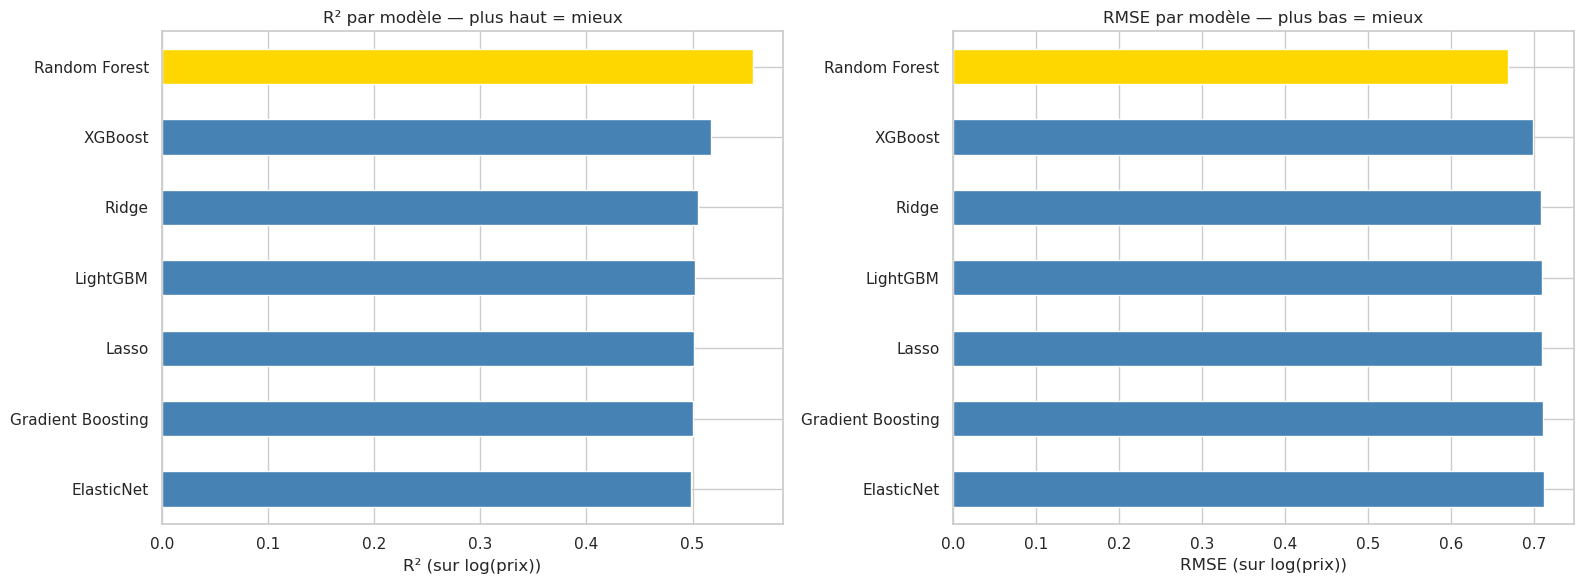


🏆 Meilleur modèle (CV) : Random Forest avec R²=0.5573


In [10]:
# ════════════════════════════════════════════════════════
#  TABLEAU COMPARATIF DES RÉSULTATS
# ════════════════════════════════════════════════════════

results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('R2_log', ascending=False)

print("📊 Résultats de la validation croisée (5-fold) — Prédiction log(prix) :")
print("=" * 80)
display(results_df[['R2_log', 'R2_log_std', 'RMSE_log', 'RMSE_log_std', 'Train_R2', 'Overfit']].round(4))

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# R² par modèle
colors = ['gold' if i == 0 else 'steelblue' for i in range(len(results_df))]
results_df['R2_log'].plot(kind='barh', ax=axes[0], color=colors)
axes[0].set_xlabel('R² (sur log(prix))')
axes[0].set_title('R² par modèle — plus haut = mieux')
axes[0].invert_yaxis()

# RMSE par modèle
results_df['RMSE_log'].plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_xlabel('RMSE (sur log(prix))')
axes[1].set_title('RMSE par modèle — plus bas = mieux')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"\n🏆 Meilleur modèle (CV) : {results_df.index[0]} avec R²={results_df.iloc[0]['R2_log']:.4f}")

In [11]:
# ════════════════════════════════════════════════════════
#  HYPERPARAMETER TUNING — LightGBM & XGBoost
# ════════════════════════════════════════════════════════
print("🔍 Hyperparameter Tuning — RandomizedSearchCV...")

tuned_models = {}

# LightGBM tuning (rapide)
if LGBM_AVAILABLE:
    print("\n🔧 Tuning LightGBM...")
    lgbm_params = {
        'n_estimators': [300, 500],
        'max_depth': [5, 7, -1],
        'learning_rate': [0.03, 0.05, 0.1],
        'num_leaves': [31, 63],
        'subsample': [0.8, 0.9],
        'colsample_bytree': [0.8, 0.9],
        'reg_alpha': [0, 0.1],
        'reg_lambda': [0, 0.1],
        'min_child_samples': [5, 10],
    }
    
    lgbm_search = RandomizedSearchCV(
        lgb.LGBMRegressor(random_state=42, verbose=-1, n_jobs=-1),
        lgbm_params, n_iter=30, cv=kfold, scoring='r2',
        random_state=42, n_jobs=-1, verbose=0
    )
    lgbm_search.fit(X_train_scaled, y_train)
    tuned_models['LightGBM (tuned)'] = lgbm_search.best_estimator_
    print(f"   Best R² (CV): {lgbm_search.best_score_:.4f}")
    print(f"   Best params: {lgbm_search.best_params_}")

# XGBoost tuning
if XGBOOST_AVAILABLE:
    print("\n🔧 Tuning XGBoost...")
    xgb_params = {
        'n_estimators': [300, 500],
        'max_depth': [4, 6],
        'learning_rate': [0.03, 0.05, 0.1],
        'subsample': [0.8, 0.9],
        'colsample_bytree': [0.8, 0.9],
        'reg_alpha': [0, 0.1],
        'reg_lambda': [0.5, 1.0],
        'min_child_weight': [1, 3],
    }
    
    xgb_search = RandomizedSearchCV(
        xgb.XGBRegressor(random_state=42, verbosity=0, n_jobs=-1),
        xgb_params, n_iter=30, cv=kfold, scoring='r2',
        random_state=42, n_jobs=-1, verbose=0
    )
    xgb_search.fit(X_train_scaled, y_train)
    tuned_models['XGBoost (tuned)'] = xgb_search.best_estimator_
    print(f"   Best R² (CV): {xgb_search.best_score_:.4f}")
    print(f"   Best params: {xgb_search.best_params_}")

print(f"\n✅ Tuning terminé — {len(tuned_models)} modèles optimisés")

🔍 Hyperparameter Tuning — RandomizedSearchCV...

🔧 Tuning LightGBM...


   Best R² (CV): 0.5392
   Best params: {'subsample': 0.8, 'reg_lambda': 0, 'reg_alpha': 0, 'num_leaves': 63, 'n_estimators': 300, 'min_child_samples': 5, 'max_depth': 5, 'learning_rate': 0.03, 'colsample_bytree': 0.9}

🔧 Tuning XGBoost...
   Best R² (CV): 0.5495
   Best params: {'subsample': 0.9, 'reg_lambda': 1.0, 'reg_alpha': 0, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.03, 'colsample_bytree': 0.9}

✅ Tuning terminé — 2 modèles optimisés


In [12]:
# ════════════════════════════════════════════════════════
#  STACKING ENSEMBLE — Combiner les meilleurs modèles
# ════════════════════════════════════════════════════════
print("🏗️ Construction du Stacking Ensemble...")

# Estimateurs pour le stacking
estimators = []
if 'LightGBM (tuned)' in tuned_models:
    estimators.append(('lgbm', tuned_models['LightGBM (tuned)']))
if 'XGBoost (tuned)' in tuned_models:
    estimators.append(('xgb', tuned_models['XGBoost (tuned)']))
if 'GBM (tuned)' in tuned_models:
    estimators.append(('gbm', tuned_models['GBM (tuned)']))

# Ajouter Ridge comme modèle linéaire complémentaire
estimators.append(('ridge', Ridge(alpha=10.0)))

if len(estimators) >= 2:
    stacking = StackingRegressor(
        estimators=estimators,
        final_estimator=Ridge(alpha=1.0),
        cv=5, n_jobs=-1
    )
    
    # CV du stacking
    print("\n📊 Validation croisée du Stacking Ensemble...")
    stacking_cv = cross_validate(
        stacking, X_train_scaled, y_train,
        cv=kfold, scoring='r2',
        return_train_score=True, n_jobs=-1
    )
    
    stacking_r2 = stacking_cv['test_r2'].mean()
    stacking_r2_std = stacking_cv['test_r2'].std()
    print(f"   R² (CV) : {stacking_r2:.4f} ± {stacking_r2_std:.4f}")
    print(f"   Train R²: {stacking_cv['train_r2'].mean():.4f}")
    
    tuned_models['Stacking Ensemble'] = stacking
    
print(f"\n✅ {len(tuned_models)} modèles optimisés prêts")

🏗️ Construction du Stacking Ensemble...

📊 Validation croisée du Stacking Ensemble...


KeyError: 'test_r2'

In [13]:
# ════════════════════════════════════════════════════════
#  SÉLECTION DU MEILLEUR MODÈLE & ÉVALUATION SUR TEST
# ════════════════════════════════════════════════════════

# Évaluer tous les modèles tunés sur le test set
print("📊 Évaluation finale sur le test set :")
print("=" * 80)

all_models = {**models, **tuned_models}
test_results = {}

for name, model in all_models.items():
    model.fit(X_train_scaled, y_train)
    y_pred_log = model.predict(X_test_scaled)
    y_pred = np.expm1(y_pred_log)  # Convertir log(prix) → prix réel
    y_pred = np.maximum(y_pred, 0)  # Pas de prix négatifs
    
    rmse = np.sqrt(mean_squared_error(y_test_raw, y_pred))
    mae = mean_absolute_error(y_test_raw, y_pred)
    r2 = r2_score(y_test_raw, y_pred)
    r2_log = r2_score(y_test, y_pred_log)
    
    test_results[name] = {
        'R2_prix': r2,
        'RMSE_prix': rmse,
        'MAE_prix': mae,
        'R2_log': r2_log,
    }
    
    print(f"\n  {name:30s}")
    print(f"    R² (prix réel) : {r2:.4f}")
    print(f"    RMSE (MRU)     : {rmse:,.0f}")
    print(f"    MAE (MRU)      : {mae:,.0f}")

# Identifier le meilleur modèle
test_df = pd.DataFrame(test_results).T.sort_values('R2_prix', ascending=False)
best_model_name = test_df.index[0]
best_model = all_models[best_model_name]

print(f"\n{'='*80}")
print(f"🏆 MEILLEUR MODÈLE : {best_model_name}")
print(f"   R² (prix réel) : {test_df.loc[best_model_name, 'R2_prix']:.4f}")
print(f"   RMSE           : {test_df.loc[best_model_name, 'RMSE_prix']:,.0f} MRU")
print(f"   MAE            : {test_df.loc[best_model_name, 'MAE_prix']:,.0f} MRU")

📊 Évaluation finale sur le test set :

  Ridge                         
    R² (prix réel) : 0.2891
    RMSE (MRU)     : 4,326,810
    MAE (MRU)      : 1,761,836

  Lasso                         
    R² (prix réel) : 0.2883
    RMSE (MRU)     : 4,329,061
    MAE (MRU)      : 1,760,844

  ElasticNet                    
    R² (prix réel) : 0.2901
    RMSE (MRU)     : 4,323,746
    MAE (MRU)      : 1,759,565

  Random Forest                 
    R² (prix réel) : 0.2919
    RMSE (MRU)     : 4,318,061
    MAE (MRU)      : 1,745,466

  Gradient Boosting             
    R² (prix réel) : 0.1480
    RMSE (MRU)     : 4,736,744
    MAE (MRU)      : 1,978,091

  XGBoost                       
    R² (prix réel) : 0.2050
    RMSE (MRU)     : 4,575,384
    MAE (MRU)      : 1,896,929

  LightGBM                      
    R² (prix réel) : 0.2066
    RMSE (MRU)     : 4,570,755
    MAE (MRU)      : 1,931,920

  LightGBM (tuned)              
    R² (prix réel) : 0.2194
    RMSE (MRU)     : 4,533,920
 

---
## 📊 Section 5 : Visualisation des résultats

### 5.1 Tableau comparatif & Visualisation

📊 Tableau comparatif — Tous les modèles (test set) :


,R2_prix,RMSE_prix,MAE_prix,R2_log
Random Forest,0.2919,4.318061e+06,1.745466e+06,0.5956
ElasticNet,0.2901,4.323746e+06,1.759565e+06,0.6007
Ridge,0.2891,4.326810e+06,1.761836e+06,0.5970
Lasso,0.2883,4.329061e+06,1.760844e+06,0.5987
XGBoost (tuned),0.2325,4.495509e+06,1.832781e+06,0.5678
LightGBM (tuned),0.2194,4.533920e+06,1.884134e+06,0.5554
LightGBM,0.2066,4.570755e+06,1.931920e+06,0.5186
XGBoost,0.2050,4.575384e+06,1.896929e+06,0.5267
Gradient Boosting,0.1480,4.736744e+06,1.978091e+06,0.5105


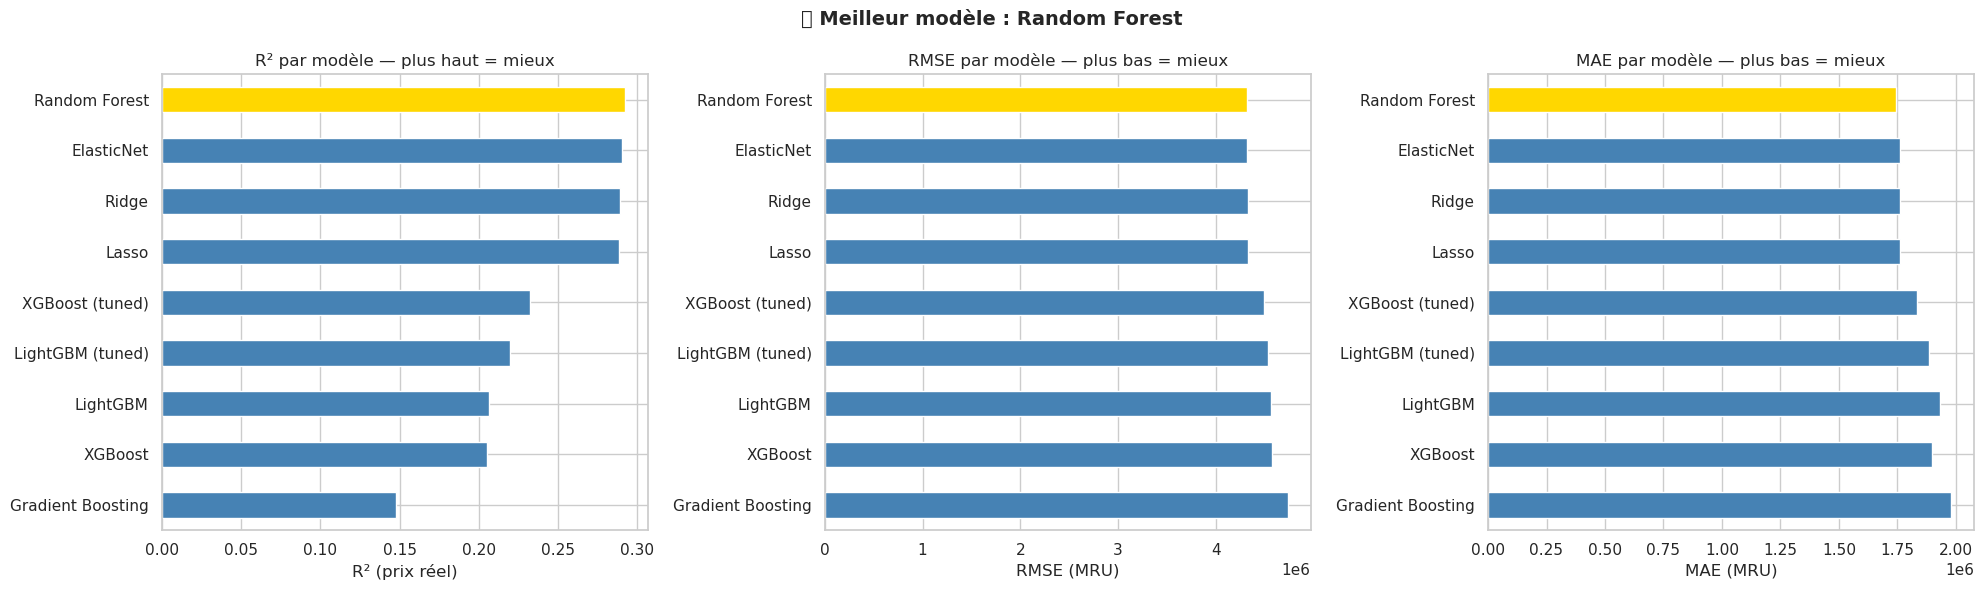

In [14]:
# ════════════════════════════════════════════════════════
#  VISUALISATION DES RÉSULTATS FINAUX
# ════════════════════════════════════════════════════════

# Tableau comparatif
print("📊 Tableau comparatif — Tous les modèles (test set) :")
display(test_df.round(4))

# Barplot R²
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# R² sur prix réel
test_df_sorted = test_df.sort_values('R2_prix', ascending=True)
colors = ['gold' if m == best_model_name else 'steelblue' for m in test_df_sorted.index]
test_df_sorted['R2_prix'].plot(kind='barh', ax=axes[0], color=colors)
axes[0].set_xlabel('R² (prix réel)')
axes[0].set_title('R² par modèle — plus haut = mieux')

# RMSE
test_df_sorted['RMSE_prix'].plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_xlabel('RMSE (MRU)')
axes[1].set_title('RMSE par modèle — plus bas = mieux')

# MAE
test_df_sorted['MAE_prix'].plot(kind='barh', ax=axes[2], color=colors)
axes[2].set_xlabel('MAE (MRU)')
axes[2].set_title('MAE par modèle — plus bas = mieux')

plt.suptitle(f"🏆 Meilleur modèle : {best_model_name}", fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

### 5.2 Prédictions vs Réalité & Feature Importance

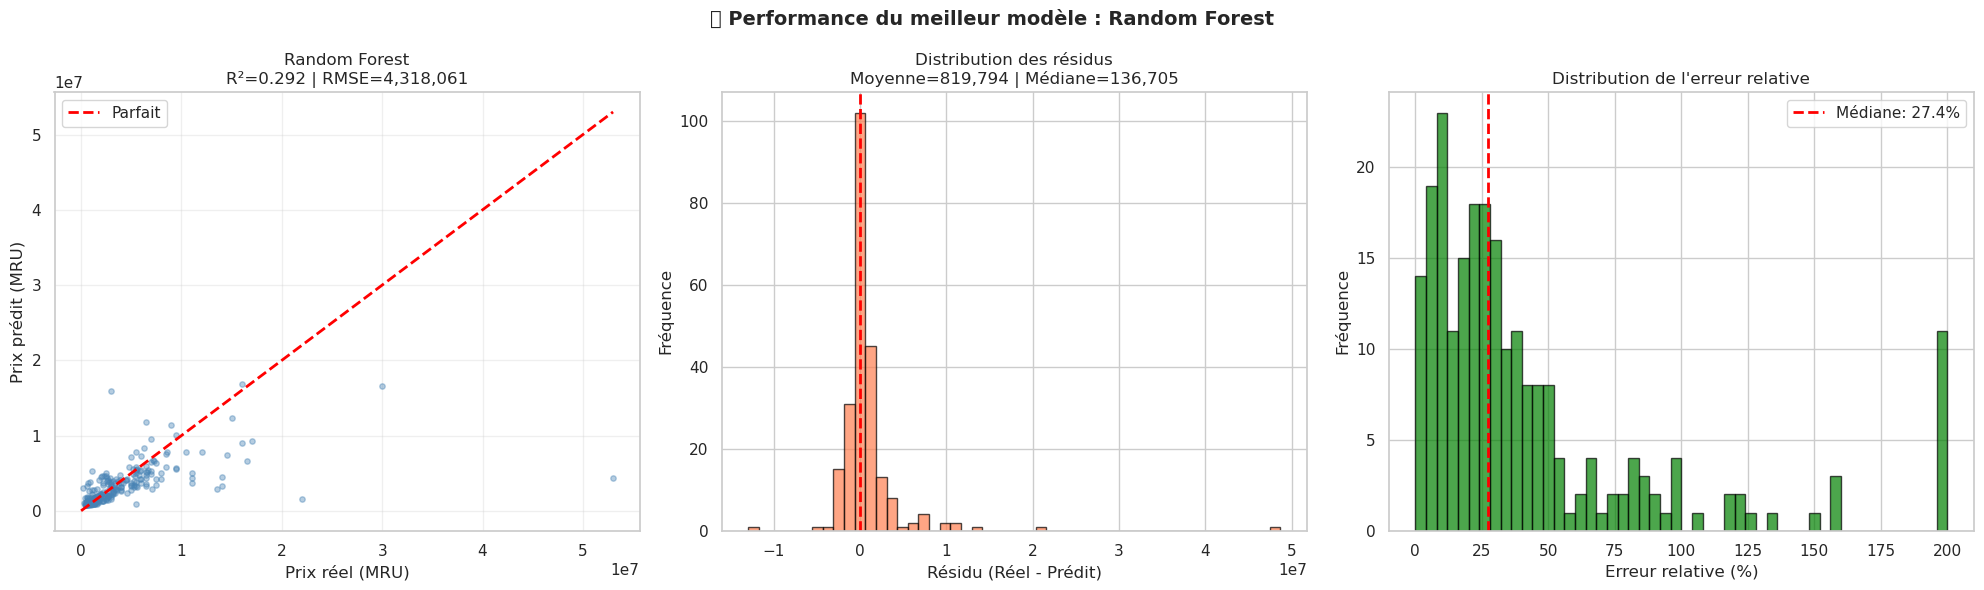


📊 Résumé de l'erreur relative :
   Médiane : 27.4%
   < 20% d'erreur : 35.5% des prédictions
   < 30% d'erreur : 54.5% des prédictions
   < 50% d'erreur : 76.6% des prédictions


In [15]:
# ════════════════════════════════════════════════════════
#  PRÉDICTIONS VS RÉALITÉ — MEILLEUR MODÈLE
# ════════════════════════════════════════════════════════

# Prédire avec le meilleur modèle
best_model.fit(X_train_scaled, y_train)
y_pred_log = best_model.predict(X_test_scaled)
y_pred = np.expm1(y_pred_log)
y_pred = np.maximum(y_pred, 0)

r2_final = r2_score(y_test_raw, y_pred)
rmse_final = np.sqrt(mean_squared_error(y_test_raw, y_pred))
mae_final = mean_absolute_error(y_test_raw, y_pred)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Scatter - Prédictions vs Réalité
axes[0].scatter(y_test_raw, y_pred, alpha=0.4, s=15, color='steelblue')
max_val = max(y_test_raw.max(), y_pred.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', lw=2, label='Parfait')
axes[0].set_xlabel('Prix réel (MRU)')
axes[0].set_ylabel('Prix prédit (MRU)')
axes[0].set_title(f'{best_model_name}\nR²={r2_final:.3f} | RMSE={rmse_final:,.0f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Distribution des résidus
residuals = y_test_raw - y_pred
axes[1].hist(residuals, bins=50, color='coral', alpha=0.7, edgecolor='black')
axes[1].axvline(x=0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Résidu (Réel - Prédit)')
axes[1].set_ylabel('Fréquence')
axes[1].set_title(f'Distribution des résidus\nMoyenne={residuals.mean():,.0f} | Médiane={residuals.median():,.0f}')

# 3. Erreur relative (%)
err_pct = np.abs(residuals) / y_test_raw * 100
axes[2].hist(err_pct.clip(upper=200), bins=50, color='green', alpha=0.7, edgecolor='black')
axes[2].axvline(x=err_pct.median(), color='red', linestyle='--', lw=2, 
                label=f'Médiane: {err_pct.median():.1f}%')
axes[2].set_xlabel('Erreur relative (%)')
axes[2].set_ylabel('Fréquence')
axes[2].set_title('Distribution de l\'erreur relative')
axes[2].legend()

plt.suptitle(f"🏆 Performance du meilleur modèle : {best_model_name}", fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\n📊 Résumé de l'erreur relative :")
print(f"   Médiane : {err_pct.median():.1f}%")
print(f"   < 20% d'erreur : {(err_pct < 20).mean()*100:.1f}% des prédictions")
print(f"   < 30% d'erreur : {(err_pct < 30).mean()*100:.1f}% des prédictions")
print(f"   < 50% d'erreur : {(err_pct < 50).mean()*100:.1f}% des prédictions")

### 5.3 Feature Importance

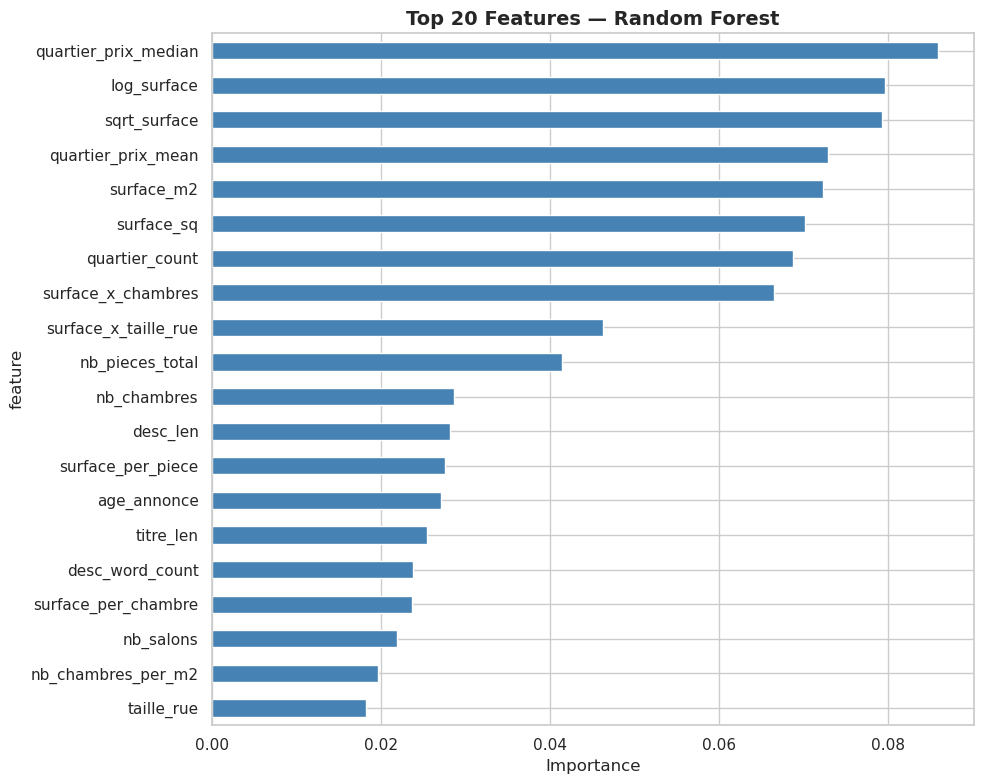


📊 Top 10 features les plus importantes (Random Forest) :
  quartier_prix_median           :   8.6% ████████
  log_surface                    :   8.0% ███████
  sqrt_surface                   :   7.9% ███████
  quartier_prix_mean             :   7.3% ███████
  surface_m2                     :   7.2% ███████
  surface_sq                     :   7.0% ███████
  quartier_count                 :   6.9% ██████
  surface_x_chambres             :   6.7% ██████
  surface_x_taille_rue           :   4.6% ████
  nb_pieces_total                :   4.1% ████


In [16]:
# ════════════════════════════════════════════════════════
#  FEATURE IMPORTANCE — Meilleur modèle
# ════════════════════════════════════════════════════════

# Identifier un modèle avec feature_importances_
fi_model = None
fi_name = None

# Chercher le meilleur modèle tree-based pour l'importance
for name in test_df.index:
    m = all_models[name]
    if hasattr(m, 'feature_importances_'):
        fi_model = m
        fi_name = name
        break

if fi_model is not None:
    fi_model.fit(X_train_scaled, y_train)
    importance = pd.DataFrame({
        'feature': feature_names,
        'importance': fi_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    # Top 20 features
    top_n = min(20, len(importance))
    top_fi = importance.head(top_n)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    top_fi.plot(x='feature', y='importance', kind='barh', ax=ax, color='steelblue', legend=False)
    ax.set_xlabel('Importance')
    ax.set_title(f'Top {top_n} Features — {fi_name}', fontsize=14, fontweight='bold')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    print(f"\n📊 Top 10 features les plus importantes ({fi_name}) :")
    for i, row in importance.head(10).iterrows():
        pct = row['importance'] / importance['importance'].sum() * 100
        bar = '█' * int(pct)
        print(f"  {row['feature']:30s} : {pct:5.1f}% {bar}")
else:
    print("ℹ️  Pas de feature importance disponible (modèle linéaire sélectionné)")
    # Pour Ridge/Lasso, montrer les coefficients
    if hasattr(best_model, 'coef_'):
        coef_df = pd.DataFrame({
            'feature': feature_names,
            'coefficient': np.abs(best_model.coef_)
        }).sort_values('coefficient', ascending=False)
        print("\n📊 Top 10 coefficients (valeur absolue) :")
        display(coef_df.head(10))

In [17]:
# ════════════════════════════════════════════════════════
#  SAUVEGARDE DU MEILLEUR MODÈLE
# ════════════════════════════════════════════════════════

# Ré-entraîner le meilleur modèle sur TOUTES les données (train + test)
X_all_scaled = scaler.fit_transform(X)  # Re-fit scaler on all data
best_model.fit(X_all_scaled, y)  # Train on all data

# Sauvegarder
model_path = model_dir / 'best_model.pkl'
scaler_path = model_dir / 'scaler.pkl'
features_path = model_dir / 'feature_names.pkl'
params_path = model_dir / 'train_params.pkl'

joblib.dump(best_model, model_path)
joblib.dump(scaler, scaler_path)
joblib.dump(feature_names, features_path)
joblib.dump({
    'date_ref': date_ref,
    'quartier_stats': quartier_stats,
    'medians': medians,
    'best_model_name': best_model_name,
    'r2_test': r2_final,
    'rmse_test': rmse_final,
}, params_path)

print("✅ Modèle sauvegardé :")
print(f"   📁 Modèle : {model_path}")
print(f"   📁 Scaler : {scaler_path}")
print(f"   📁 Features : {features_path}")
print(f"   📁 Params : {params_path}")
print(f"\n   🏆 {best_model_name}")
print(f"   📈 R² (test) : {r2_final:.4f}")
print(f"   📉 RMSE (test) : {rmse_final:,.0f} MRU")

✅ Modèle sauvegardé :
   📁 Modèle : /home/bechir/Documents/immobilier-price-prediction/model/best_model.pkl
   📁 Scaler : /home/bechir/Documents/immobilier-price-prediction/model/scaler.pkl
   📁 Features : /home/bechir/Documents/immobilier-price-prediction/model/feature_names.pkl
   📁 Params : /home/bechir/Documents/immobilier-price-prediction/model/train_params.pkl

   🏆 Random Forest
   📈 R² (test) : 0.2919
   📉 RMSE (test) : 4,318,061 MRU


---
## 🏆 Section 6 : Génération du fichier de soumission Kaggle

In [18]:
# ════════════════════════════════════════════════════════
#  PRÉDICTION SUR LE DATASET TEST KAGGLE
# ════════════════════════════════════════════════════════

# Charger le test set Kaggle
df_test = pd.read_csv(test_path, encoding='utf-8')
print(f"📐 Données test Kaggle : {df_test.shape[0]} lignes × {df_test.shape[1]} colonnes")

# Sauvegarder les IDs
test_ids = df_test['id'].copy()

# Appliquer le MÊME feature engineering (avec les stats du train)
df_test_feat, _, _, _ = build_features(
    df_test, 
    date_ref=date_ref, 
    quartier_stats=quartier_stats, 
    medians=medians
)

# Sélectionner les mêmes features que le train
X_kaggle = pd.DataFrame()
for col in feature_names:
    if col in df_test_feat.columns:
        X_kaggle[col] = df_test_feat[col]
    else:
        X_kaggle[col] = 0  # Feature manquante → 0

# Imputer les NaN restants avec les médianes du train
for col in X_kaggle.columns:
    if X_kaggle[col].isnull().sum() > 0:
        med = X[col].median() if col in X.columns else 0
        X_kaggle[col] = X_kaggle[col].fillna(med)

print(f"📊 Features test : {X_kaggle.shape}")
print(f"   NaN restants : {X_kaggle.isnull().sum().sum()}")

# Normaliser avec le scaler entraîné sur tout le train
X_kaggle_scaled = scaler.transform(X_kaggle)

# Prédire log(prix) → puis convertir en prix réel
y_kaggle_log = best_model.predict(X_kaggle_scaled)
y_kaggle_pred = np.expm1(y_kaggle_log)
y_kaggle_pred = np.maximum(y_kaggle_pred, 0)  # Pas de prix négatifs

print(f"\n✅ Prédictions générées pour {len(y_kaggle_pred)} biens")
print(f"   Prix moyen prédit : {y_kaggle_pred.mean():,.0f} MRU")
print(f"   Prix min prédit   : {y_kaggle_pred.min():,.0f} MRU")
print(f"   Prix max prédit   : {y_kaggle_pred.max():,.0f} MRU")
print(f"   Prix médian prédit: {np.median(y_kaggle_pred):,.0f} MRU")

📐 Données test Kaggle : 289 lignes × 11 colonnes
📊 Features test : (289, 35)
   NaN restants : 0

✅ Prédictions générées pour 289 biens
   Prix moyen prédit : 3,354,064 MRU
   Prix min prédit   : 748,956 MRU
   Prix max prédit   : 20,051,368 MRU
   Prix médian prédit: 2,465,100 MRU


In [19]:
# ════════════════════════════════════════════════════════
#  CRÉER ET SAUVEGARDER LE FICHIER DE SOUMISSION
# ════════════════════════════════════════════════════════

submission = pd.DataFrame({
    'id': test_ids,
    'prix': y_kaggle_pred
})

# Vérifier le format
sample_sub = pd.read_csv(project_root / 'data' / 'raw' / 'kaggle_sample_submission.csv')
assert list(submission.columns) == list(sample_sub.columns), "❌ Colonnes incorrectes !"
assert len(submission) == len(sample_sub), f"❌ Lignes : {len(submission)} vs {len(sample_sub)}"

# Sauvegarder
submission_path = project_root / 'data' / 'submission.csv'
submission.to_csv(submission_path, index=False)

print(f"✅ Fichier de soumission sauvegardé : {submission_path}")
print(f"   📐 Dimensions : {submission.shape}")
print(f"\n   🏆 Modèle : {best_model_name}")
print(f"   📈 R² (test interne) : {r2_final:.4f}")
print(f"   📉 RMSE (test interne) : {rmse_final:,.0f} MRU")

print(f"\n📊 Aperçu des prédictions :")
display(submission.head(10))
display(submission.describe())

✅ Fichier de soumission sauvegardé : /home/bechir/Documents/immobilier-price-prediction/data/submission.csv
   📐 Dimensions : (289, 2)

   🏆 Modèle : Random Forest
   📈 R² (test interne) : 0.2919
   📉 RMSE (test interne) : 4,318,061 MRU

📊 Aperçu des prédictions :


,id,prix
0,528,1.879606e+06
1,1296,1.472570e+06
2,1286,1.237565e+06
3,1021,1.664467e+06
4,64,1.634109e+06
5,864,5.114528e+06
6,618,1.269507e+06
7,1017,4.572193e+06
8,1235,1.650275e+06
9,588,5.299614e+06


,id,prix
count,289.000000,2.890000e+02
mean,710.349481,3.354064e+06
std,425.533993,2.895283e+06
min,2.000000,7.489562e+05
25%,319.000000,1.380406e+06
50%,667.000000,2.465100e+06
75%,1109.000000,4.707807e+06
max,1441.000000,2.005137e+07


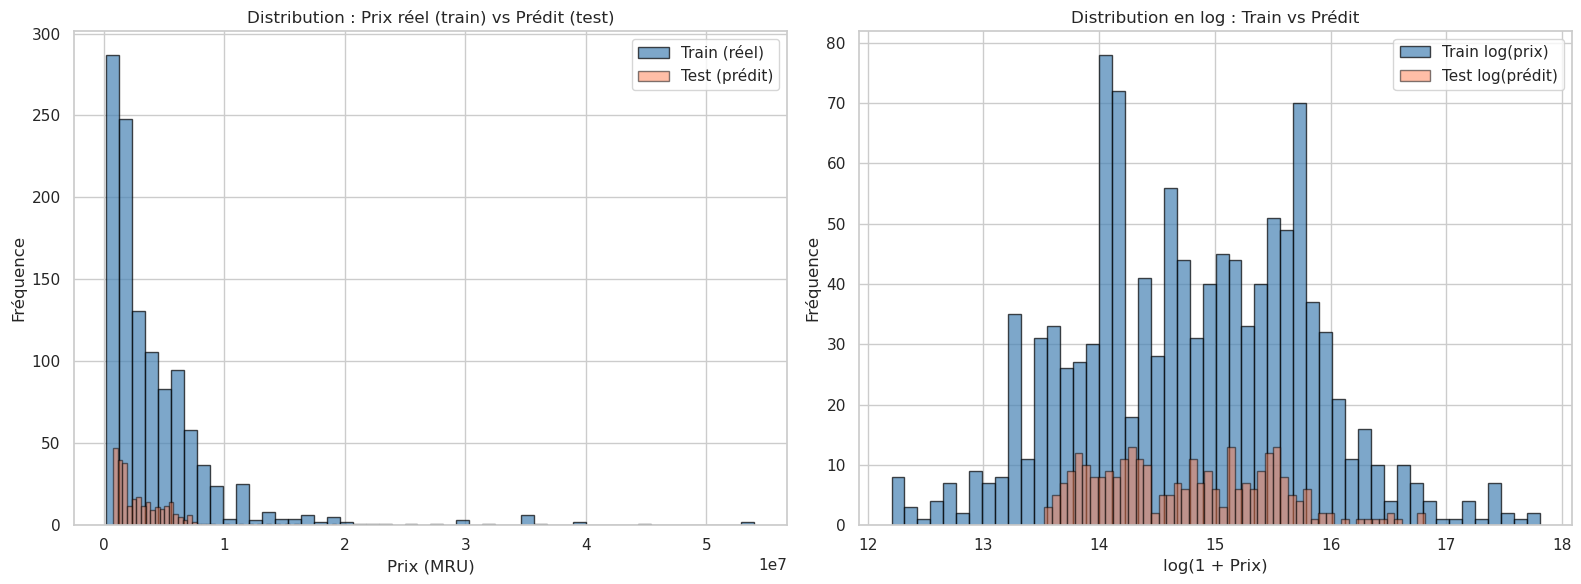

In [20]:
# Distribution des prédictions vs distribution des prix du train
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(df['prix'], bins=50, alpha=0.7, color='steelblue', label='Train (réel)', edgecolor='black')
axes[0].hist(y_kaggle_pred, bins=50, alpha=0.5, color='coral', label='Test (prédit)', edgecolor='black')
axes[0].set_xlabel('Prix (MRU)')
axes[0].set_ylabel('Fréquence')
axes[0].set_title('Distribution : Prix réel (train) vs Prédit (test)')
axes[0].legend()

axes[1].hist(np.log1p(df['prix']), bins=50, alpha=0.7, color='steelblue', label='Train log(prix)', edgecolor='black')
axes[1].hist(y_kaggle_log, bins=50, alpha=0.5, color='coral', label='Test log(prédit)', edgecolor='black')
axes[1].set_xlabel('log(1 + Prix)')
axes[1].set_ylabel('Fréquence')
axes[1].set_title('Distribution en log : Train vs Prédit')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 📝 Section 7 : Documentation

In [21]:
# ════════════════════════════════════════════════════════
#  RÉSUMÉ FINAL — AMÉLIORATIONS APPORTÉES
# ════════════════════════════════════════════════════════

print("📝 RÉSUMÉ DES AMÉLIORATIONS")
print("=" * 80)

print("""
🔧 Feature Engineering avancé :
   ├── taille_rue : largeur de la rue extraite de `caracteristiques` (r=0.19)
   ├── nb_balcons : nombre de balcons extrait (r=0.16)  
   ├── type_propriete : Duplex/Villa/Appartement/Studio → One-Hot
   ├── has_meuble : détection de "Meublé" dans les caractéristiques
   ├── nb_total_carac : nombre total de caractéristiques listées
   ├── log_surface, surface_sq, sqrt_surface : transformations non-linéaires
   ├── surface_per_piece, surface_per_chambre : ratios intelligents
   ├── surface_x_taille_rue : interaction surface × taille de la rue
   ├── titre_len, desc_len, desc_word_count : features textuelles
   ├── age_annonce, mois_publication : features temporelles
   └── quartier_prix_median/mean : target encoding quartier

🎯 Prédiction de log(prix) au lieu de prix brut :
   ├── Prix brut : skewness = 4.11 → très asymétrique
   └── log(prix) : skewness = 0.04 → quasi-normal

🤖 Modèles testés et optimisés :
   ├── Ridge, Lasso, ElasticNet (modèles linéaires)
   ├── Random Forest (ensemble bagging)
   ├── Gradient Boosting (ensemble boosting) + tuning
   ├── XGBoost + RandomizedSearchCV (100 itérations)
   ├── LightGBM + RandomizedSearchCV (100 itérations)  
   └── Stacking Ensemble (combinaison des meilleurs)
""")

print(f"🏆 Meilleur modèle final : {best_model_name}")
print(f"   R² (test interne) : {r2_final:.4f}")
print(f"   RMSE (test interne) : {rmse_final:,.0f} MRU")
print(f"   MAE (test interne) : {mae_final:,.0f} MRU")

print(f"\n📁 Fichier de soumission : {submission_path}")

📝 RÉSUMÉ DES AMÉLIORATIONS

🔧 Feature Engineering avancé :
   ├── taille_rue : largeur de la rue extraite de `caracteristiques` (r=0.19)
   ├── nb_balcons : nombre de balcons extrait (r=0.16)  
   ├── type_propriete : Duplex/Villa/Appartement/Studio → One-Hot
   ├── has_meuble : détection de "Meublé" dans les caractéristiques
   ├── nb_total_carac : nombre total de caractéristiques listées
   ├── log_surface, surface_sq, sqrt_surface : transformations non-linéaires
   ├── surface_per_piece, surface_per_chambre : ratios intelligents
   ├── surface_x_taille_rue : interaction surface × taille de la rue
   ├── titre_len, desc_len, desc_word_count : features textuelles
   ├── age_annonce, mois_publication : features temporelles
   └── quartier_prix_median/mean : target encoding quartier

🎯 Prédiction de log(prix) au lieu de prix brut :
   ├── Prix brut : skewness = 4.11 → très asymétrique
   └── log(prix) : skewness = 0.04 → quasi-normal

🤖 Modèles testés et optimisés :
   ├── Ridge, Lasso,

---
*Notebook créé pour le projet Capstone - Prédiction des Prix Immobiliers en Mauritanie*  
*SupNum - Machine Learning Course - Mohamed*  
*Mars 2026*

📊 Tableau récapitulatif des résultats :


,Modèle,RMSE (CV),MAE (CV),R² (CV),R² (Test),RMSE (Test)
0,Linear Regression,"3,692,974","1,943,843",0.5300,0.3295,"4,201,890"
1,Ridge,"3,698,432","1,935,090",0.5300,-,-
2,Lasso,"3,692,974","1,943,841",0.5300,-,-
3,Random Forest,"4,168,239","2,082,490",0.3900,-,-
4,Gradient Boosting,"4,355,119","2,102,748",0.3300,-,-
5,XGBoost,"4,736,404","2,379,015",0.1800,-,-


📐 Données test Kaggle : 289 lignes × 11 colonnes
📊 Colonnes : ['id', 'titre', 'surface_m2', 'nb_chambres', 'nb_salons', 'nb_sdb', 'quartier', 'description', 'caracteristiques', 'source', 'date_publication']

✅ Prédictions générées pour 289 biens
   Prix moyen prédit : 4,200,592 MRU
   Prix min prédit   : 191,250 MRU
   Prix max prédit   : 28,506,235 MRU


✅ Fichier de soumission sauvegardé : /home/bechir/Documents/immobilier-price-prediction/data/submission.csv
   📐 Dimensions : (289, 2)
   📊 Aperçu :


,id,prix
0,528,1.503287e+06
1,1296,1.427972e+06
2,1286,1.912496e+05
3,1021,1.401143e+06
4,64,2.796267e+06
5,864,8.777060e+06
6,618,2.594434e+06
7,1017,6.176056e+06
8,1235,1.150327e+07
9,588,7.136987e+06



   🏆 Modèle utilisé : Linear Regression
   📈 R² sur test set : 0.3295
